The goal here is to answer: **Can each spatial transcriptomics spot be linked to a usable H&E image patch?**

The output should be:

`spot_id → x/y coordinate → H&E patch`

In [1]:
# Libraries for data manipulation and visualization
from pathlib import Path
import h5py
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


# function for finding parent directory
def find_project_root(start_path=None, project_name="HistoGeneAlign"):
    if start_path is None:
        start_path = Path.cwd()
    start_path = Path(start_path).resolve()

    for p in [start_path] + list(start_path.parents):
        if p.name == project_name:
            return p

    for p in [start_path] + list(start_path.parents):
        if (p / "data").exists() and (p / "notebooks").exists():
            return p

    raise RuntimeError("Could not find project root.")

# Defining the paths
PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "hest"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PATCH_DIR = PROJECT_ROOT / "data" / "patches"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
PATCH_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_ID = "TENX95"

# Defining paths for the patch H5 data and the spot metadata CSV file
PATCH_H5_PATH = RAW_DIR / "patches" / f"{SAMPLE_ID}.h5"
SPOT_METADATA_PATH = PROCESSED_DIR / f"{SAMPLE_ID}_spot_metadata_qc.csv"

# Verification of the paths
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Patch H5 exists:", PATCH_H5_PATH.exists(), PATCH_H5_PATH)
print("Spot metadata exists:", SPOT_METADATA_PATH.exists(), SPOT_METADATA_PATH)

PROJECT_ROOT: C:\Users\Hareen\Desktop\HistoGeneAlign
Patch H5 exists: True C:\Users\Hareen\Desktop\HistoGeneAlign\data\raw\hest\patches\TENX95.h5
Spot metadata exists: True C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_spot_metadata_qc.csv


### Loading spot metadata

In [2]:
spot_metadata = pd.read_csv(SPOT_METADATA_PATH)

print("Spot metadata shape:", spot_metadata.shape)
display(spot_metadata.head())

print("\nColumns:")
print(spot_metadata.columns.tolist())

Spot metadata shape: (11845, 12)


,sample_id,spot_id,x,y,expression_available,coordinate_available,wsi_available,patch_h5_available,library_size,detected_genes,x_thumb,y_thumb
0,TENX95,000x000,249.515782,263.81301,True,True,True,True,0,0,4.654227,4.893503
1,TENX95,000x001,720.104017,263.81301,True,True,True,True,0,0,13.432127,4.893503
2,TENX95,000x002,1190.692253,263.81301,True,True,True,True,0,0,22.210027,4.893503
3,TENX95,000x003,1661.280488,263.81301,True,True,True,True,0,0,30.987926,4.893503
4,TENX95,000x004,2131.868723,263.81301,True,True,True,True,0,0,39.765826,4.893503



Columns:
['sample_id', 'spot_id', 'x', 'y', 'expression_available', 'coordinate_available', 'wsi_available', 'patch_h5_available', 'library_size', 'detected_genes', 'x_thumb', 'y_thumb']


### Inspecting the H5 file structure

In [3]:
def print_h5_structure(h5_path):
    with h5py.File(h5_path, "r") as f:
        print("H5 file keys:")
        print(list(f.keys()))

        print("\nFull H5 structure:")

        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"DATASET | {name} | shape={obj.shape} | dtype={obj.dtype}")
            elif isinstance(obj, h5py.Group):
                print(f"GROUP   | {name}")

        f.visititems(visitor)

print_h5_structure(PATCH_H5_PATH)

H5 file keys:
['barcode', 'coords', 'img']

Full H5 structure:
DATASET | barcode | shape=(7592, 1) | dtype=object
DATASET | coords | shape=(7592, 2) | dtype=int64
DATASET | img | shape=(7592, 224, 224, 3) | dtype=uint8


The barcode is a string like spotID.

The coords is the coordinates, your (x,y)

The img has a (N x H x W x 3) pattern representing RGB image patches

### Automatically Identifying likely patch dataset

In [4]:
candidate_patch_datasets = []

with h5py.File(PATCH_H5_PATH, "r") as f:
    def find_patch_candidates(name, obj):
        if isinstance(obj, h5py.Dataset):
            shape = obj.shape
            dtype = obj.dtype

            if len(shape) == 4:
                candidate_patch_datasets.append({
                    "name": name,
                    "shape": shape,
                    "dtype": str(dtype)
                })

    f.visititems(find_patch_candidates)

candidate_patch_df = pd.DataFrame(candidate_patch_datasets)

print("Candidate patch datasets:")
display(candidate_patch_df)

Candidate patch datasets:


,name,shape,dtype
0,img,"(7592, 224, 224, 3)",uint8


This `img` is likely the image patch array

### Automatically identifying coordinate & ID datasets

In [5]:
candidate_coord_datasets = []
candidate_id_datasets = []

with h5py.File(PATCH_H5_PATH, "r") as f:
    def find_candidates(name, obj):
        if isinstance(obj, h5py.Dataset):
            shape = obj.shape
            dtype = obj.dtype
            lname = name.lower()

            # coordinate-like
            if (
                len(shape) == 2 and shape[1] in [2, 3, 4]
            ) or any(k in lname for k in ["coord", "position", "spatial", "location"]):
                candidate_coord_datasets.append({
                    "name": name,
                    "shape": shape,
                    "dtype": str(dtype)
                })

            # id-like
            if any(k in lname for k in ["barcode", "spot", "id", "name"]):
                candidate_id_datasets.append({
                    "name": name,
                    "shape": shape,
                    "dtype": str(dtype)
                })

    f.visititems(find_candidates)

print("Candidate coordinate datasets:")
display(pd.DataFrame(candidate_coord_datasets))

print("Candidate ID datasets:")
display(pd.DataFrame(candidate_id_datasets))

Candidate coordinate datasets:


,name,shape,dtype
0,coords,"(7592, 2)",int64


Candidate ID datasets:


,name,shape,dtype
0,barcode,"(7592, 1)",object


### Previewing patches

Patch dataset: img
Shape: (7592, 224, 224, 3)
Dtype: uint8


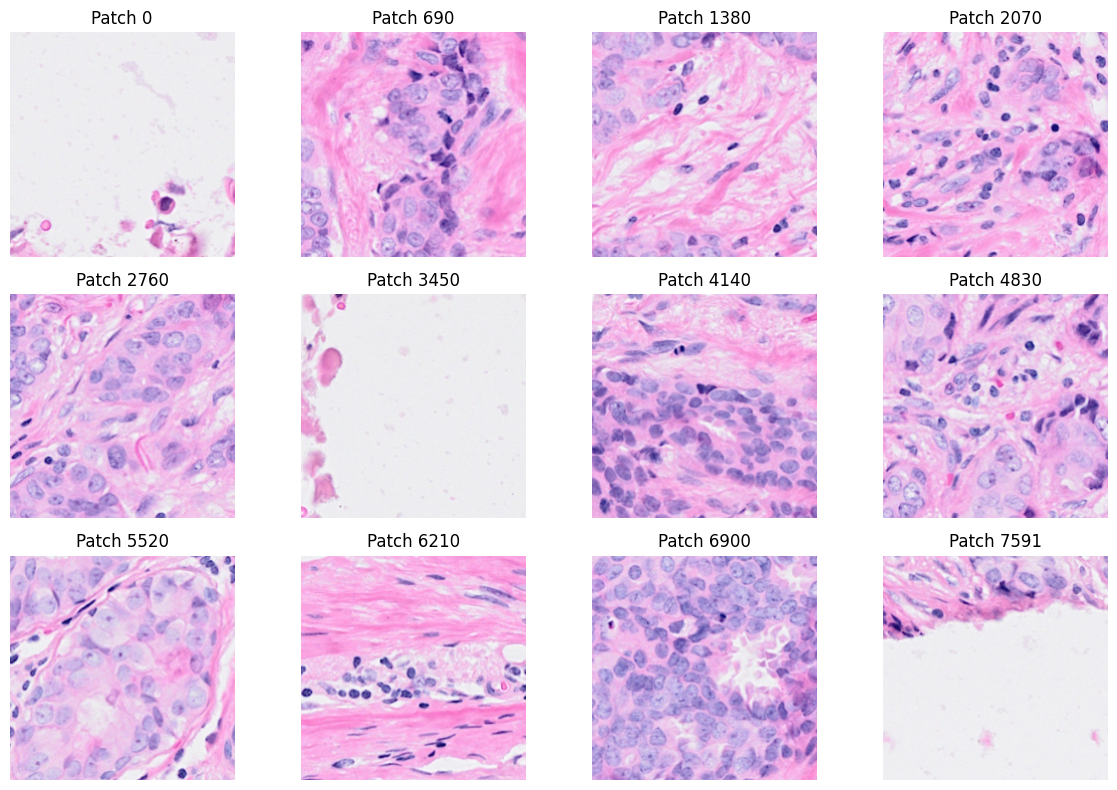

In [6]:
PATCH_DATASET_NAME = "img"

with h5py.File(PATCH_H5_PATH, "r") as f:
    patches = f[PATCH_DATASET_NAME]

    print("Patch dataset:", PATCH_DATASET_NAME)
    print("Shape:", patches.shape)
    print("Dtype:", patches.dtype)

    n_preview = min(12, patches.shape[0])
    indices = np.linspace(0, patches.shape[0] - 1, n_preview).astype(int)

    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(indices):
        patch = patches[idx]

        # Handle channel-first format: C x H x W
        if patch.ndim == 3 and patch.shape[0] in [1, 3, 4]:
            patch = np.transpose(patch, (1, 2, 0))

        # Handle float images
        if patch.dtype != np.uint8:
            patch_min = patch.min()
            patch_max = patch.max()
            if patch_max > patch_min:
                patch = (255 * (patch - patch_min) / (patch_max - patch_min)).astype(np.uint8)
            else:
                patch = np.zeros_like(patch, dtype=np.uint8)

        plt.subplot(3, 4, i + 1)
        plt.imshow(patch)
        plt.title(f"Patch {idx}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{SAMPLE_ID}_h5_patch_preview.png", dpi=300)
    plt.show()

This preview confirms that `patches/TENX95.h5` contains usable H&E image patches. The patches show clear histology morphology with the expected H&E staining pattern:
- pink regions  → eosin-stained cytoplasm / extracellular matrix / stroma
- purple regions → hematoxylin-stained nuclei
- white regions → background, empty space, or low-tissue area

### Checking patch count v/s spot count

In [7]:
with h5py.File(PATCH_H5_PATH, "r") as f:
    n_patches = f[PATCH_DATASET_NAME].shape[0]

n_spots = len(spot_metadata)

print("Number of patches:", n_patches)
print("Number of spots in metadata:", n_spots)
print("Difference:", n_patches - n_spots)

Number of patches: 7592
Number of spots in metadata: 11845
Difference: -4253


The patch-count check shows that the H5 patch file contains fewer image patches than the full spot metadata table.

This is expected as full spatial grid includes both tissue-containing spots + background spots.

### Building `aligned_image_gene_table` from TENX95 patch H5 + spot metadata

Input:

    patches/TENX95.h5
       barcode -> patch-associated spot IDs
       coords  -> patch-associated coordinates
       img     -> patch image array
       
    processed/TENX95_spot_metadata_qc.csv
       spot-level metadata from AnnData

Output:

    processed/TENX95_aligned_image_gene_table.csv

In [10]:
# ------------------------------------------------------------
#  Robust H5 string decoder helper functions
# ------------------------------------------------------------

def decode_h5_value(x):
    """
    I am decoding one H5 value into a clean Python string.

    This handles:
    - bytes
    - numpy bytes
    - object arrays
    - one-element arrays like [b'000x001']
    """
    if isinstance(x, bytes):
        return x.decode("utf-8", errors="replace")

    if isinstance(x, np.bytes_):
        return x.astype(str)

    if isinstance(x, np.ndarray):
        if x.size == 1:
            return decode_h5_value(x.item())
        return "_".join([decode_h5_value(v) for v in x.ravel()])

    return str(x)


def clean_spot_id(x):
    """
    I am standardizing spot IDs so H5 barcodes and AnnData spot IDs
    can be compared safely.
    """
    x = decode_h5_value(x)
    x = x.strip()
    x = x.replace("b'", "").replace("'", "")
    x = x.replace('b"', "").replace('"', "")
    return x

In [11]:
# ------------------------------------------------------------
# Loading patch metadata from TENX95.h5
# ------------------------------------------------------------

H5_BARCODE_KEY = "barcode"
H5_COORD_KEY = "coords"
H5_IMAGE_KEY = "img"

with h5py.File(PATCH_H5_PATH, "r") as f:
    barcodes_raw = f[H5_BARCODE_KEY][:]
    coords = np.asarray(f[H5_COORD_KEY][:])
    image_shape = f[H5_IMAGE_KEY].shape
    image_dtype = f[H5_IMAGE_KEY].dtype

patch_spot_ids = np.array([clean_spot_id(x) for x in barcodes_raw], dtype=str)

patch_table = pd.DataFrame({
    "sample_id": SAMPLE_ID,
    "patch_index": np.arange(len(patch_spot_ids)),
    "spot_id": patch_spot_ids,
    "patch_x": coords[:, 0],
    "patch_y": coords[:, 1],
    "valid_patch": True,
})

print("Patch table shape:", patch_table.shape)
print("Patch image shape:", image_shape)
print("Patch image dtype:", image_dtype)

display(patch_table.head())

Patch table shape: (7592, 6)
Patch image shape: (7592, 224, 224, 3)
Patch image dtype: uint8


,sample_id,patch_index,spot_id,patch_x,patch_y,valid_patch
0,TENX95,0,006x022,10339,2824,True
1,TENX95,1,006x023,10810,2824,True
2,TENX95,2,006x024,11280,2824,True
3,TENX95,3,006x025,11751,2824,True
4,TENX95,4,006x026,12221,2824,True


In [12]:
# ============================================================
# Validating H5 barcode-to-spot matching
# ============================================================

print("Number of H5 patches:", len(patch_table))
print("Unique H5 spot IDs:", patch_table["spot_id"].nunique())
print("Duplicate H5 spot IDs:", patch_table["spot_id"].duplicated().sum())

print("\nNumber of spot metadata rows:", len(spot_metadata))
print("Unique metadata spot IDs:", spot_metadata["spot_id"].astype(str).nunique())

metadata_spot_set = set(spot_metadata["spot_id"].astype(str))
patch_spot_set = set(patch_table["spot_id"].astype(str))

overlap = patch_spot_set.intersection(metadata_spot_set)

print("\nPatch spot IDs found in metadata:", len(overlap))
print("Patch IDs missing from metadata:", len(patch_spot_set - metadata_spot_set))
print("Metadata IDs without patches:", len(metadata_spot_set - patch_spot_set))

print("\nOverlap fraction relative to patches:")
print(len(overlap) / len(patch_spot_set))

print("\nFirst few patch spot IDs:")
print(patch_table["spot_id"].head(10).tolist())

Number of H5 patches: 7592
Unique H5 spot IDs: 7592
Duplicate H5 spot IDs: 0

Number of spot metadata rows: 11845
Unique metadata spot IDs: 11845

Patch spot IDs found in metadata: 7592
Patch IDs missing from metadata: 0
Metadata IDs without patches: 4253

Overlap fraction relative to patches:
1.0

First few patch spot IDs:
['006x022', '006x023', '006x024', '006x025', '006x026', '006x027', '006x028', '006x029', '006x030', '006x031']


The output here means that there is a perfect overlap and that the H5 `barcode` field directly solves the patch-to-spot mapping

In [13]:
# ============================================================
# Building aligned image-gene table
# ============================================================

# Make sure metadata spot_id is clean string
spot_metadata_clean = spot_metadata.copy()
spot_metadata_clean["spot_id"] = spot_metadata_clean["spot_id"].astype(str)

# Add AnnData row index from the spot metadata order
# This assumes spot_metadata was created directly from adata.obs_names order.
spot_metadata_clean["ann_data_row"] = np.arange(len(spot_metadata_clean))

# Merge H5 patch table with AnnData-derived spot metadata
aligned_image_gene_table = patch_table.merge(
    spot_metadata_clean,
    on=["sample_id", "spot_id"],
    how="left",
    validate="one_to_one"
)

# If image embeddings were extracted from H5 patches in the same order,
# then embedding_row is the same as patch_index.
# This is valid only if 04_embedding_extraction.ipynb loops through img[0], img[1], ...
aligned_image_gene_table["embedding_row"] = aligned_image_gene_table["patch_index"]

# Expression validity
aligned_image_gene_table["valid_expression"] = (
    aligned_image_gene_table["expression_available"].fillna(False).astype(bool)
    & aligned_image_gene_table["coordinate_available"].fillna(False).astype(bool)
)

# Keep final important columns in a clean order
final_cols = [
    "sample_id",
    "spot_id",
    "patch_index",
    "ann_data_row",
    "embedding_row",
    "x",
    "y",
    "patch_x",
    "patch_y",
    "library_size",
    "detected_genes",
    "valid_patch",
    "valid_expression",
    "expression_available",
    "coordinate_available",
    "wsi_available",
    "patch_h5_available",
]

# Keep thumbnail columns if they exist
optional_cols = ["x_thumb", "y_thumb"]
final_cols = final_cols + [c for c in optional_cols if c in aligned_image_gene_table.columns]

aligned_image_gene_table = aligned_image_gene_table[final_cols]

print("Aligned table shape:", aligned_image_gene_table.shape)
display(aligned_image_gene_table.head())

print("\nMissing values per column:")
display(aligned_image_gene_table.isna().sum())

Aligned table shape: (7592, 19)


,sample_id,spot_id,patch_index,ann_data_row,embedding_row,x,y,patch_x,patch_y,library_size,detected_genes,valid_patch,valid_expression,expression_available,coordinate_available,wsi_available,patch_h5_available,x_thumb,y_thumb
0,TENX95,006x022,0,640,0,10602.456959,3087.342422,10339,2824,1006,177,True,True,True,True,True,True,197.768021,57.267529
1,TENX95,006x023,1,641,1,11073.045194,3087.342422,10810,2824,1219,239,True,True,True,True,True,True,206.545921,57.267529
2,TENX95,006x024,2,642,2,11543.633429,3087.342422,11280,2824,5068,283,True,True,True,True,True,True,215.323821,57.267529
3,TENX95,006x025,3,643,3,12014.221664,3087.342422,11751,2824,6534,299,True,True,True,True,True,True,224.101720,57.267529
4,TENX95,006x026,4,644,4,12484.809900,3087.342422,12221,2824,3516,272,True,True,True,True,True,True,232.879620,57.267529



Missing values per column:


sample_id               0
spot_id                 0
patch_index             0
ann_data_row            0
embedding_row           0
x                       0
y                       0
patch_x                 0
patch_y                 0
library_size            0
detected_genes          0
valid_patch             0
valid_expression        0
expression_available    0
coordinate_available    0
wsi_available           0
patch_h5_available      0
x_thumb                 0
y_thumb                 0
dtype: int64

In [14]:
# =========================================================================================
# # Coordinate sanity check
#
# I am checking whether H5 coords match the AnnData-derived coordinates in spot_metadata.
# =========================================================================================

aligned_image_gene_table["coord_dx"] = (
    aligned_image_gene_table["patch_x"].astype(float)
    - aligned_image_gene_table["x"].astype(float)
)

aligned_image_gene_table["coord_dy"] = (
    aligned_image_gene_table["patch_y"].astype(float)
    - aligned_image_gene_table["y"].astype(float)
)

aligned_image_gene_table["coord_distance"] = np.sqrt(
    aligned_image_gene_table["coord_dx"] ** 2
    + aligned_image_gene_table["coord_dy"] ** 2
)

print("Coordinate distance summary:")
display(aligned_image_gene_table["coord_distance"].describe())

print("\nLargest coordinate mismatches:")
display(
    aligned_image_gene_table
    .sort_values("coord_distance", ascending=False)
    .head(10)[
        [
            "spot_id",
            "patch_index",
            "x",
            "y",
            "patch_x",
            "patch_y",
            "coord_dx",
            "coord_dy",
            "coord_distance",
        ]
    ]
)

Coordinate distance summary:


count    7592.000000
mean      372.672330
std         0.287874
min       372.004280
25%       372.461934
50%       372.670022
75%       372.877877
max       373.335304
Name: coord_distance, dtype: float64


Largest coordinate mismatches:


,spot_id,patch_index,x,y,patch_x,patch_y,coord_dx,coord_dy,coord_distance
1979,036x045,1979,21425.98637,17204.989481,21162,16941,-263.98637,-263.989481,373.335304
1996,036x062,1996,29425.98637,17204.989481,29162,16941,-263.98637,-263.989481,373.335304
3487,053x045,3487,21425.98637,25204.989481,21162,24941,-263.98637,-263.989481,373.335304
3504,053x062,3504,29425.98637,25204.989481,29162,24941,-263.98637,-263.989481,373.335304
3538,053x096,3538,45425.98637,25204.989481,45162,24941,-263.98637,-263.989481,373.335304
3470,053x028,3470,13425.98637,25204.989481,13162,24941,-263.98637,-263.989481,373.335304
1962,036x028,1962,13425.98637,17204.989481,13162,16941,-263.98637,-263.989481,373.335304
657,019x062,657,29425.98637,9204.989481,29162,8941,-263.98637,-263.989481,373.335304
640,019x045,640,21425.98637,9204.989481,21162,8941,-263.98637,-263.989481,373.335304
3453,053x011,3453,5425.98637,25204.989481,5162,24941,-263.98637,-263.989481,373.335304


Small coordinate differences are okay if one source is rounded to intand the other source stores float coordinates.

Large systematic differences mean the coordinate systems differ, but direct barcode matching is still the stronger mapping if spot IDs match.

In [15]:
# ============================================================
# Saving the aligned image-gene table
# ============================================================

ALIGNED_TABLE_PATH = PROCESSED_DIR / f"{SAMPLE_ID}_aligned_image_gene_table.csv"

aligned_image_gene_table.to_csv(ALIGNED_TABLE_PATH, index=False)

print("Saved aligned image-gene table:")
print(ALIGNED_TABLE_PATH)

print("\nFinal usable aligned pairs:")
print("Total aligned rows:", len(aligned_image_gene_table))
print("Valid patch rows:", aligned_image_gene_table["valid_patch"].sum())
print("Valid expression rows:", aligned_image_gene_table["valid_expression"].sum())

print("\nRows passing simple MVP QC:")
mvp_qc_mask = (
    aligned_image_gene_table["valid_patch"]
    & aligned_image_gene_table["valid_expression"]
    & (aligned_image_gene_table["library_size"] >= 1000)
    & (aligned_image_gene_table["detected_genes"] >= 100)
)

print(mvp_qc_mask.sum())

Saved aligned image-gene table:
C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_aligned_image_gene_table.csv

Final usable aligned pairs:
Total aligned rows: 7592
Valid patch rows: 7592
Valid expression rows: 7592

Rows passing simple MVP QC:
7530


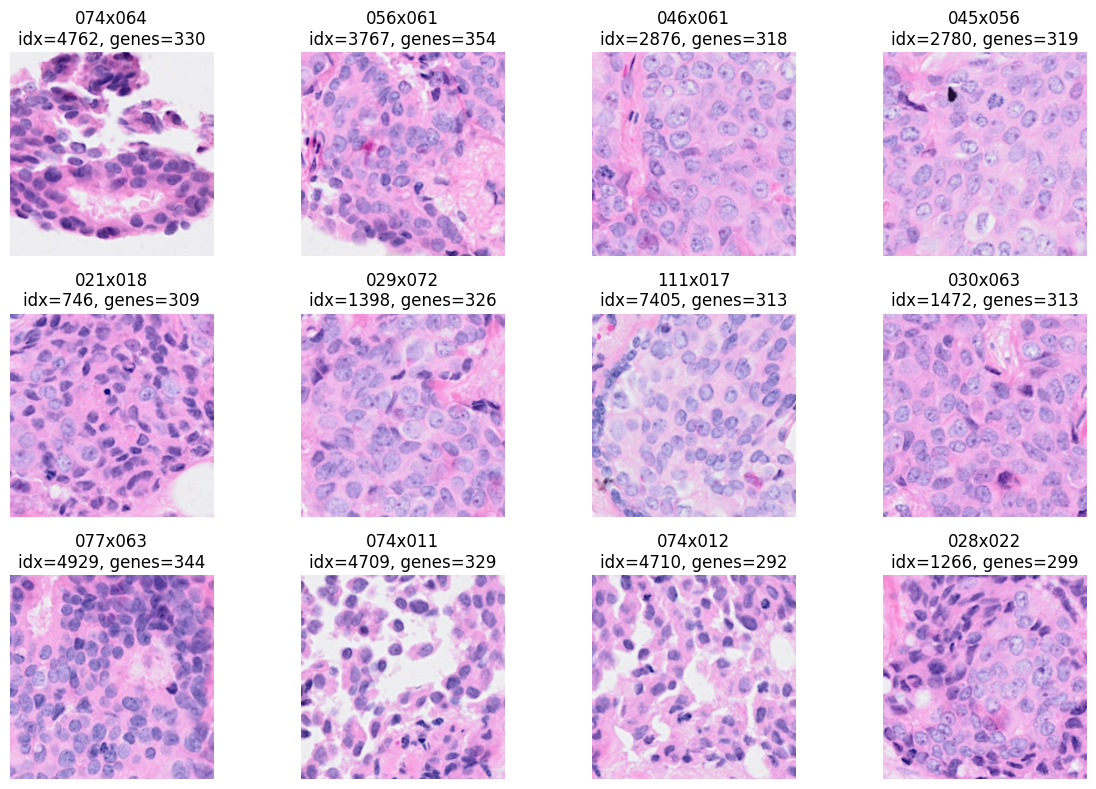

Saved mapped patch preview:
C:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures\TENX95_mapped_patch_preview.png


In [16]:
# ============================================================
# Preview mapped patches using aligned table rows
# ============================================================

import matplotlib.pyplot as plt

n_preview = 12

preview_df = (
    aligned_image_gene_table
    .sort_values(["library_size", "detected_genes"], ascending=False)
    .head(n_preview)
    .reset_index(drop=True)
)

with h5py.File(PATCH_H5_PATH, "r") as f:
    img_dataset = f[H5_IMAGE_KEY]

    plt.figure(figsize=(12, 8))

    for i, row in preview_df.iterrows():
        patch_idx = int(row["patch_index"])
        patch = img_dataset[patch_idx]

        plt.subplot(3, 4, i + 1)
        plt.imshow(patch)
        plt.title(
            f"{row['spot_id']}\n"
            f"idx={patch_idx}, genes={int(row['detected_genes'])}"
        )
        plt.axis("off")

    plt.tight_layout()

    out_path = FIGURE_DIR / f"{SAMPLE_ID}_mapped_patch_preview.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

print("Saved mapped patch preview:")
print(out_path)